## Task 1

In [302]:
import numpy as np
import matplotlib.pyplot as plt

In [303]:
lynx = np.array([[209.70, 368.42], [157.63, 332.16], [118.82, 284.21], [80.95, 224.56], [43.08, 244.44], [20.36, 266.67], [-4.26, 293.57], [2.37, 263.16], [-20.36, 292.40], [-39.29, 299.42], [-21.30, 259.65],
[-50.65, 267.84], [-39.29, 242.11], [-55.38, 240.94], [-100.83, 300.58], [-149.11, 345.03], [-172.78, 361.40], [-189.82, 300.58], [-192.66, 225.73], [-181.30, 145.03], [-168.05, 104.09], [-184.14, 66.67],
[-186.98, 31.58], [-183.20, 3.51], [-208.76, -4.68], [-197.40, -29.24], [-182.25, -44.44], [-203.08, -43.27], [-172.78, -92.40], [-131.12, -126.32], [-101.78, -147.37], [-74.32, -163.74], [-110.30, -224.56],
[-143.43, -287.72], [-161.42, -240.94], [-282.60, -221.05], [-388.64, -205.85], [-370.65, -301.75], [-339.41, -397.66], [18.46, -397.66], [345.09, -400.00], [359.29, -378.95], [367.81, -342.69], [346.98, -
362.57], [363.08, -302.92], [357.40, -243.27], [348.88, -266.67], [336.57, -201.17], [290.18, -135.67], [240.00, -118.13], [258.93, -164.91], [257.99, -228.07], [252.31, -271.35], [256.09, -333.33],
[247.57, -359.06], [230.53, -307.60], [194.56, -238.60], [160.47, -181.29], [120.71, -149.71], [165.21, -132.16], [201.18, -100.58], [183.20, -99.42], [221.07, -73.68], [253.25, -24.56], [222.01, -23.39],
[251.36, -1.17], [262.72, 24.56], [234.32, 25.73], [214.44, 42.11], [202.13, 60.82], [220.12, 101.75], [234.32, 160.23], [240.00, 230.41], [232.43, 316.96]
])
L = lynx.T
print(L.shape)   # (2, 74)

(2, 74)


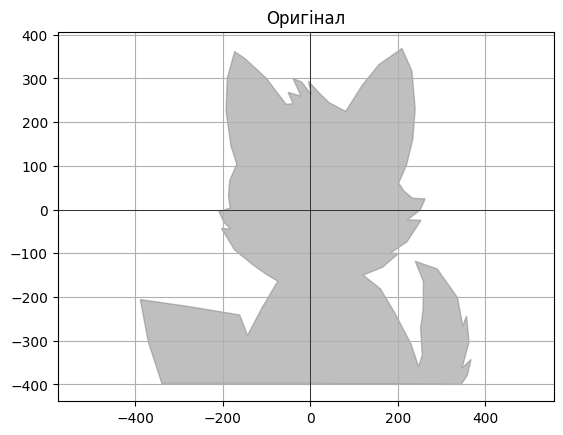

In [304]:
plt.fill(L[0], L[1], color='gray', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.axis('equal')
plt.grid(True)
plt.title('Оригінал')
plt.show()

In [305]:
def plot_transform(original, transformed, A, title):
    print(title)
    print(np.round(A, 3))   # округлюємо, щоб матриця читалась
    plt.fill(original[0], original[1], color='gray', alpha=0.3, label='Оригінал')
    plt.fill(transformed[0], transformed[1], color='blue', alpha=0.5, label='Після')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.title(title)
    plt.show()

In [306]:
def plot_steps(steps, title):
    # steps — список кортежів (точки, матриця, підпис)
    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4), sharex=True, sharey=True)
    for ax, (P, A, name) in zip(axes, steps):
        ax.fill(L[0], L[1], color='gray', alpha=0.3)      # оригінал для порівняння
        ax.fill(P[0], P[1], color='blue', alpha=0.5)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_aspect('equal')
        ax.set_title(name)
        print(name)
        print(np.round(A, 3), '\n')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 1. Stretch

In [307]:
def stretch(X, a, b):
    X = X.copy()                  # копіюємо, щоб не змінити оригінал
    A = np.array([[a, 0],
                  [0, b]])        # матриця розтягу
    return A @ X, A               # множимо матрицю на точки

Stretch (1.5, 0.7)
[[1.5 0. ]
 [0.  0.7]]


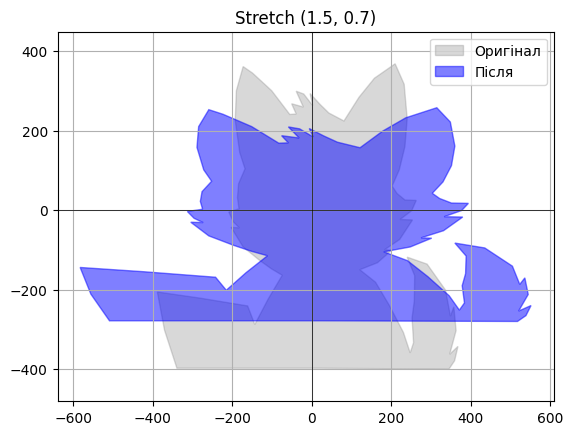

In [308]:
L2, A = stretch(L, 1.5, 0.7)
plot_transform(L, L2, A, 'Stretch (1.5, 0.7)')

Stretch (2, 1)
[[2 0]
 [0 1]]


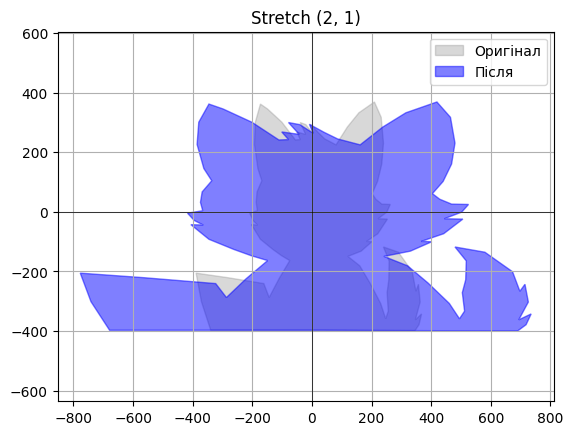

Stretch (1, 0.5)
[[1.  0. ]
 [0.  0.5]]


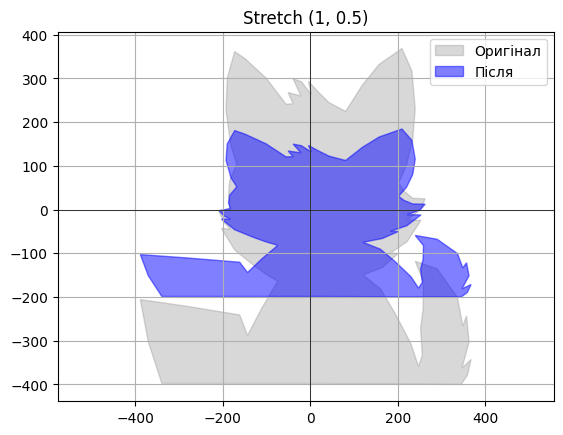

Stretch (1.5, 1.5)
[[1.5 0. ]
 [0.  1.5]]


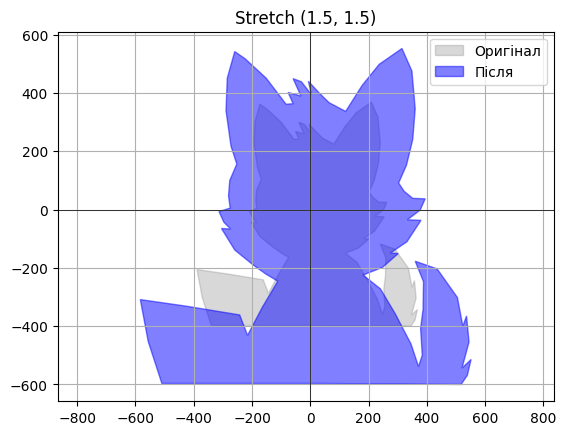

Stretch (-1, 1)
[[-1  0]
 [ 0  1]]


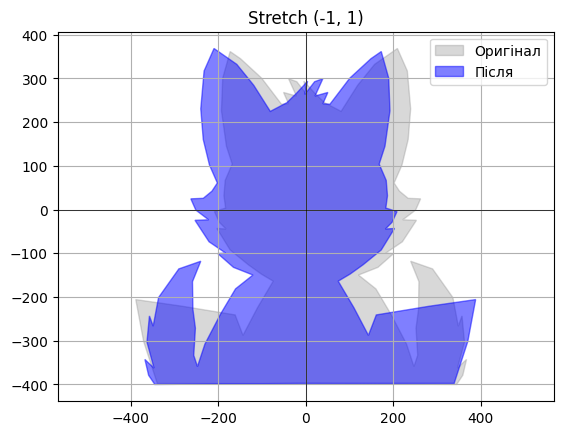

Stretch (1, 0)
[[1 0]
 [0 0]]


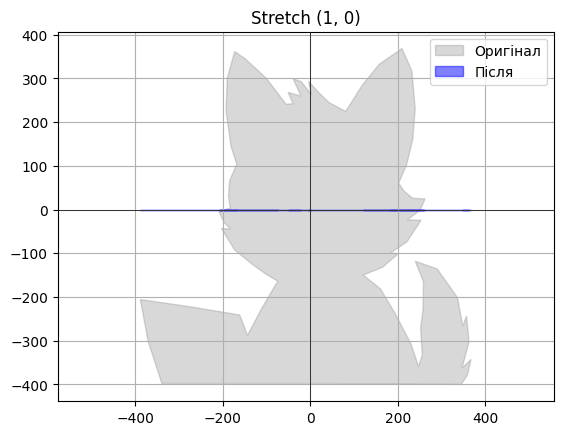

In [309]:
# Дослідження: як a і b впливають на результат
for a, b in [(2, 1), (1, 0.5), (1.5, 1.5), (-1, 1), (1, 0)]:
    L2, A = stretch(L, a, b)
    plot_transform(L, L2, A, f'Stretch ({a}, {b})')

## 2. Shear

In [310]:
def shear(X, a, b):
    X = X.copy()
    A = np.array([[1, a],
                  [b, 1]])        # матриця зсуву
    return A @ X, A

Shear (0.5, 0)
[[1.  0.5]
 [0.  1. ]]


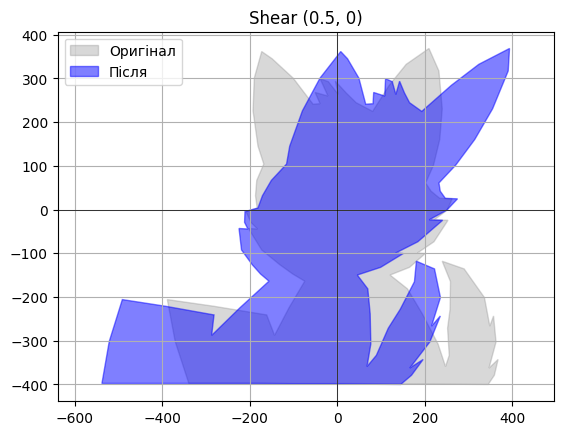

In [311]:
L2, A = shear(L, 0.5, 0)
plot_transform(L, L2, A, 'Shear (0.5, 0)')

Shear (0.5, 0), det = 1.00
[[1.  0.5]
 [0.  1. ]]


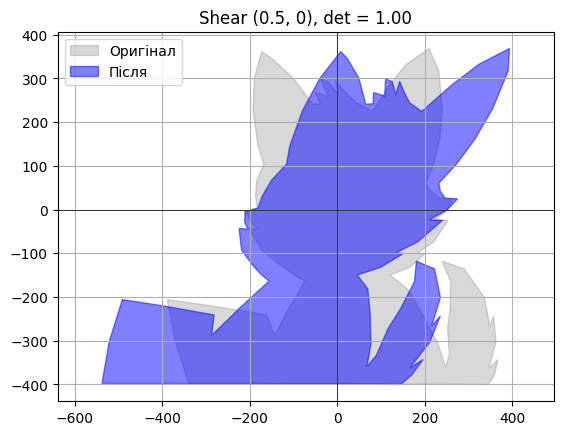

Shear (0, 0.5), det = 1.00
[[1.  0. ]
 [0.5 1. ]]


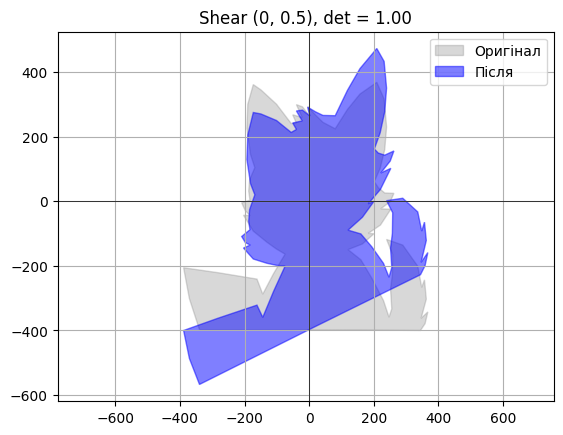

Shear (0.5, 0.5), det = 0.75
[[1.  0.5]
 [0.5 1. ]]


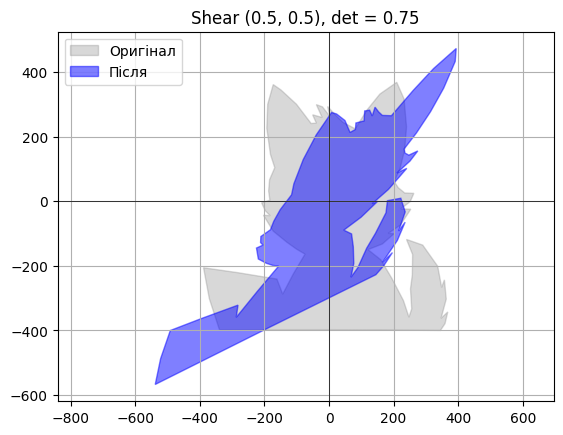

Shear (-0.5, 0), det = 1.00
[[ 1.  -0.5]
 [ 0.   1. ]]


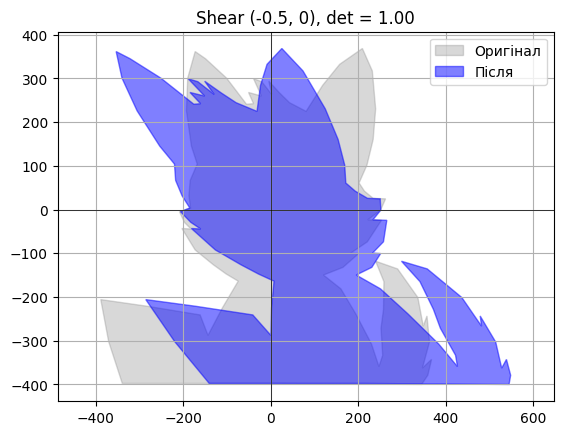

Shear (1, 1), det = 0.00
[[1 1]
 [1 1]]


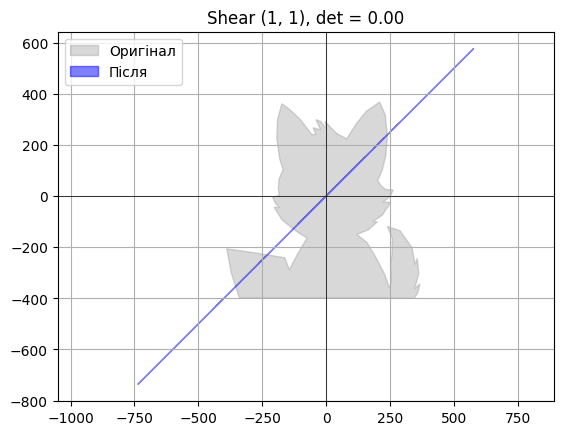

In [312]:
# Дослідження: горизонтальний, вертикальний, обидва, від'ємний, вироджений (a*b = 1)
for a, b in [(0.5, 0), (0, 0.5), (0.5, 0.5), (-0.5, 0), (1, 1)]:
    L2, A = shear(L, a, b)
    plot_transform(L, L2, A, f'Shear ({a}, {b}), det = {np.linalg.det(A):.2f}')

## 3. Reflection

In [313]:
def reflection(X, a, b):
    X = X.copy()
    A = (1 / (a**2 + b**2)) * np.array([[a**2 - b**2, 2*a*b],
                                        [2*a*b,       b**2 - a**2]])
    return A @ X, A

Reflection (1, 1): пряма y = x
[[0. 1.]
 [1. 0.]]


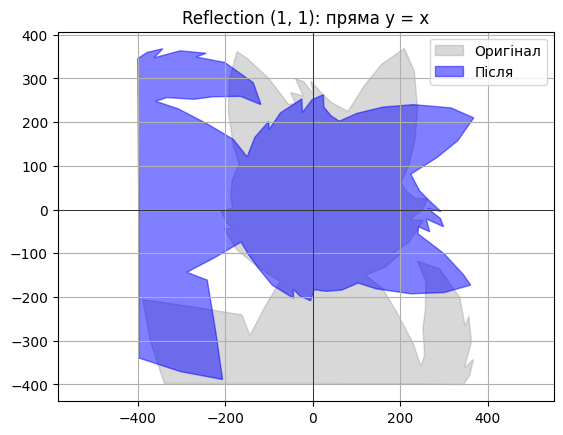

In [314]:
L2, A = reflection(L, 1, 1)
plot_transform(L, L2, A, 'Reflection (1, 1): пряма y = x')

Reflection (1, 0)
[[ 1.  0.]
 [ 0. -1.]]


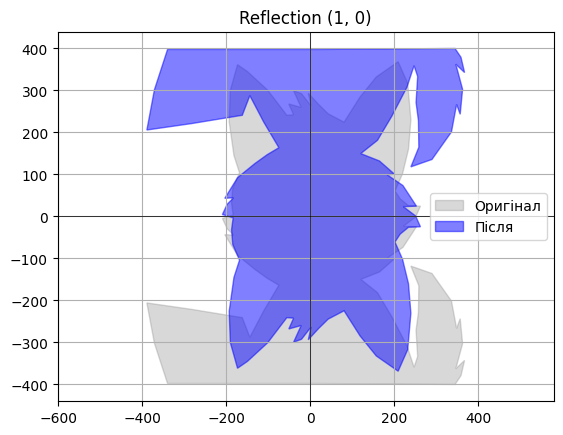

Reflection (0, 1)
[[-1.  0.]
 [ 0.  1.]]


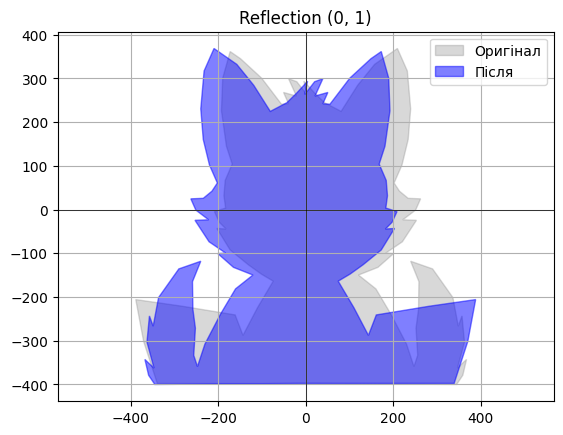

Reflection (1, 1)
[[0. 1.]
 [1. 0.]]


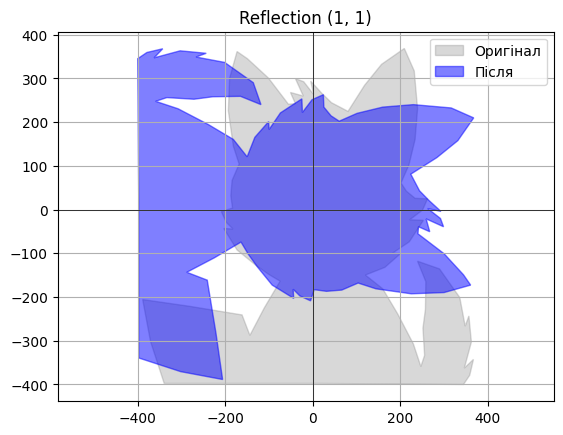

Reflection (1, -1)
[[ 0. -1.]
 [-1.  0.]]


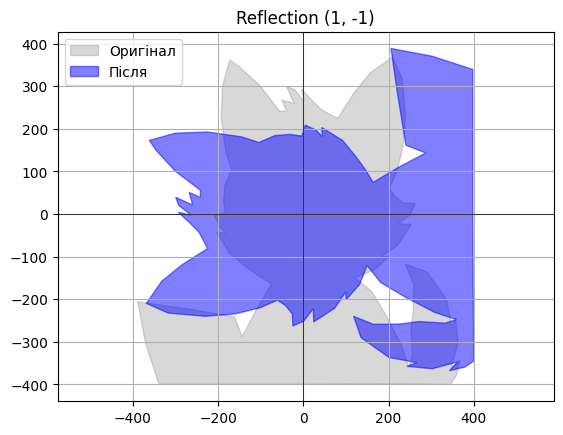

Reflection (2, 2)
[[0. 1.]
 [1. 0.]]


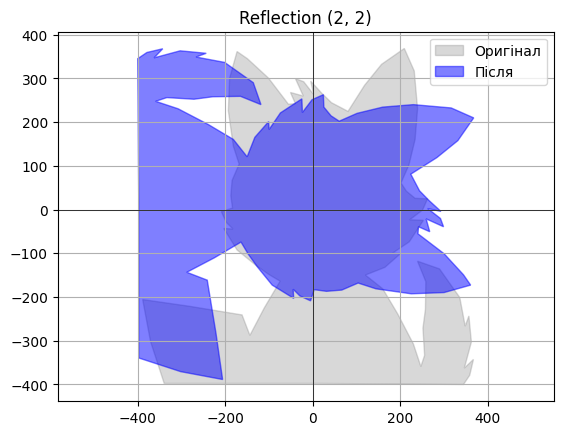

In [315]:
# Дослідження: вісь x, вісь y, y = x, y = -x, і (2, 2) для порівняння з (1, 1)
for a, b in [(1, 0), (0, 1), (1, 1), (1, -1), (2, 2)]:
    L2, A = reflection(L, a, b)
    plot_transform(L, L2, A, f'Reflection ({a}, {b})')

## 4. Rotation

In [316]:
def rotation(X, theta):
    X = X.copy()
    c, s = np.cos(theta), np.sin(theta)
    A = np.array([[c, -s],
                  [s,  c]])       # матриця повороту
    return A @ X, A

Rotation 45°
[[ 0.707 -0.707]
 [ 0.707  0.707]]


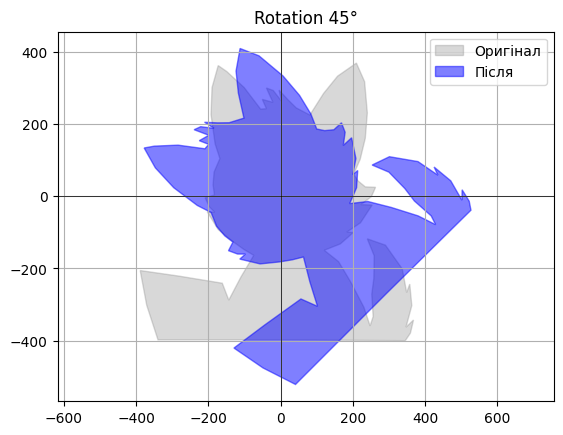

In [317]:
L2, A = rotation(L, np.pi / 4)
plot_transform(L, L2, A, 'Rotation 45°')

Rotation 45°
[[ 0.707 -0.707]
 [ 0.707  0.707]]


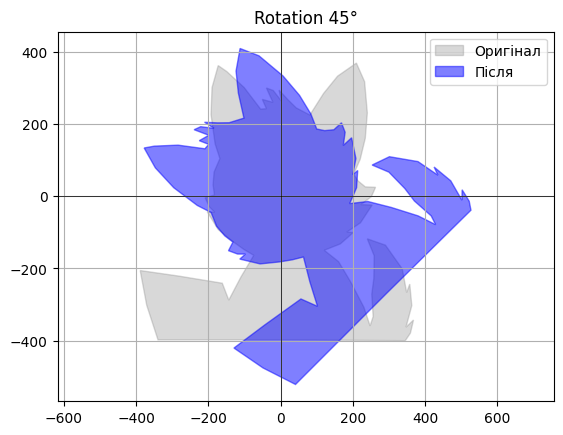

Rotation 90°
[[ 0. -1.]
 [ 1.  0.]]


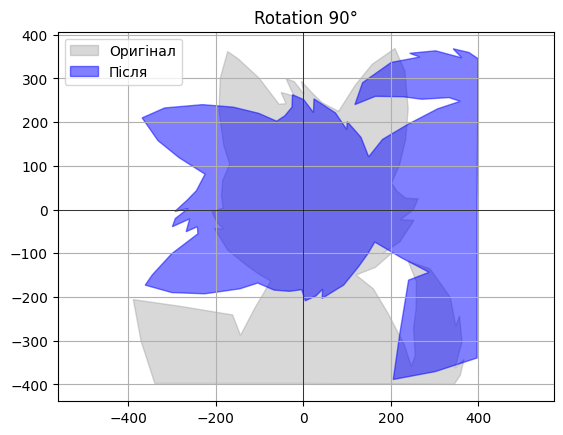

Rotation 180°
[[-1. -0.]
 [ 0. -1.]]


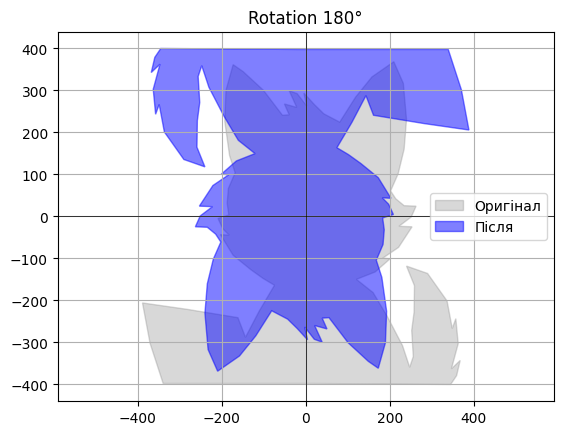

Rotation -45°
[[ 0.707  0.707]
 [-0.707  0.707]]


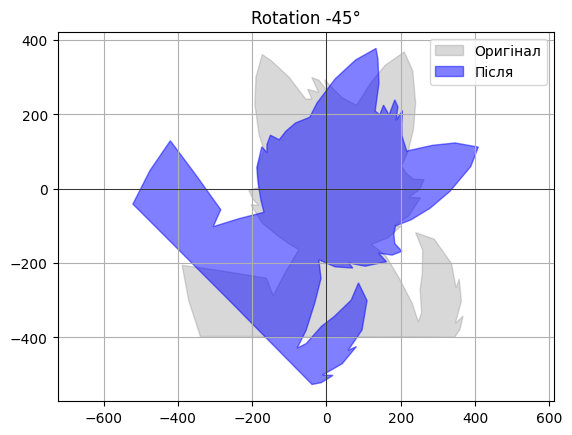

Rotation 360°
[[ 1.  0.]
 [-0.  1.]]


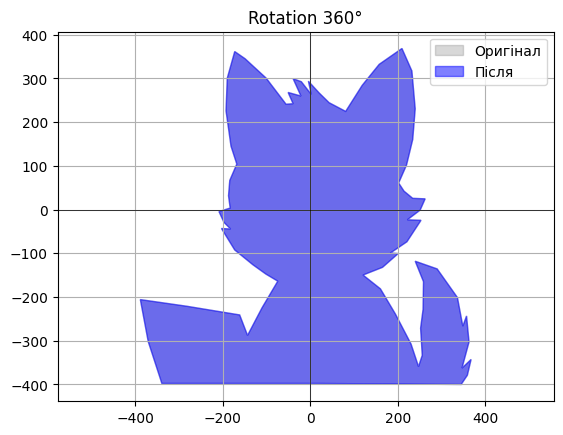

In [318]:
# Дослідження: різні кути (у градусах для зручності)
for deg in [45, 90, 180, -45, 360]:
    L2, A = rotation(L, np.radians(deg))
    plot_transform(L, L2, A, f'Rotation {deg}°')

Stretch
[[1.5 0. ]
 [0.  0.7]] 

Shear
[[1.  0.5]
 [0.  1. ]] 

Rotation
[[ 0.707 -0.707]
 [ 0.707  0.707]] 

Підсумок M = R·Sh·St
[[ 1.061 -0.247]
 [ 1.061  0.742]] 



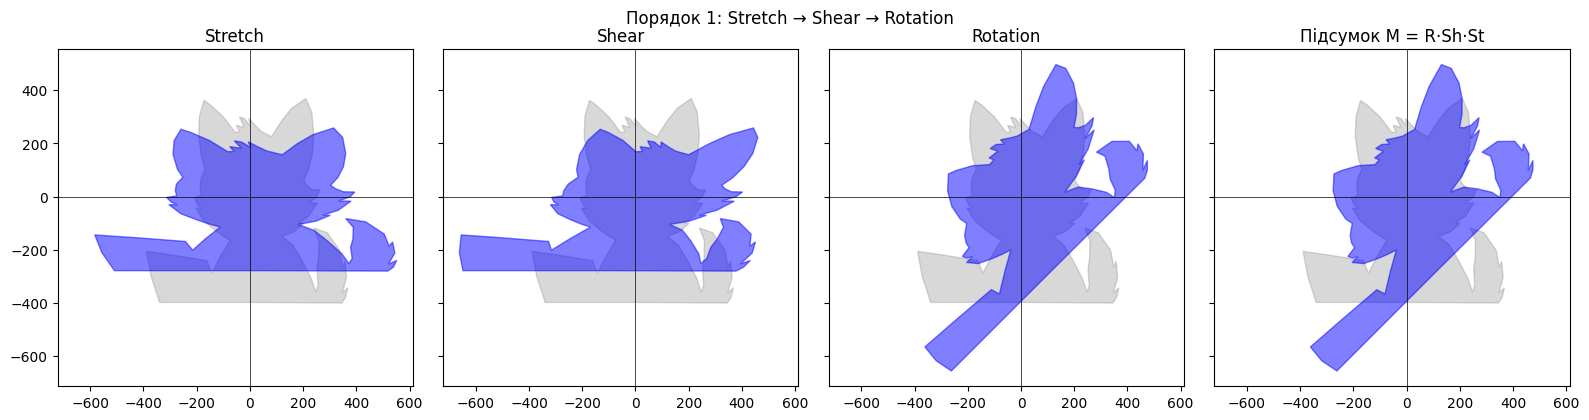

In [319]:
# Порядок 1: Stretch → Shear → Rotation
L1, St = stretch(L, 1.5, 0.7)
L2, Sh = shear(L1, 0.5, 0)
L3, R  = rotation(L2, np.pi / 4)
M1 = R @ Sh @ St

plot_steps([(L1, St, 'Stretch'),
            (L2, Sh, 'Shear'),
            (L3, R,  'Rotation'),
            (L3, M1, 'Підсумок M = R·Sh·St')],
           'Порядок 1: Stretch → Shear → Rotation')

Rotation
[[ 0.707 -0.707]
 [ 0.707  0.707]] 

Shear
[[1.  0.5]
 [0.  1. ]] 

Stretch
[[1.5 0. ]
 [0.  0.7]] 

Підсумок M = St·Sh·R
[[ 1.591 -0.53 ]
 [ 0.495  0.495]] 



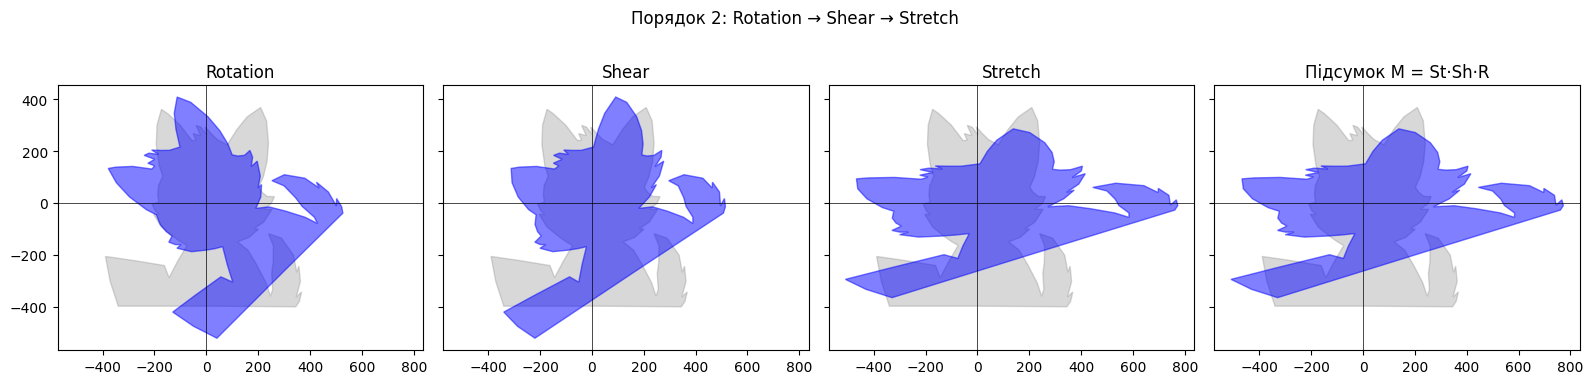

In [320]:
# Порядок 2: Rotation → Shear → Stretch
P1, R  = rotation(L, np.pi / 4)
P2, Sh = shear(P1, 0.5, 0)
P3, St = stretch(P2, 1.5, 0.7)
M2 = St @ Sh @ R

plot_steps([(P1, R,  'Rotation'),
            (P2, Sh, 'Shear'),
            (P3, St, 'Stretch'),
            (P3, M2, 'Підсумок M = St·Sh·R')],
           'Порядок 2: Rotation → Shear → Stretch')

Shear
[[1.  0.5]
 [0.  1. ]] 

Rotation
[[ 0.707 -0.707]
 [ 0.707  0.707]] 

Stretch
[[1.5 0. ]
 [0.  0.7]] 

Підсумок M = St·R·Sh
[[ 1.061 -0.53 ]
 [ 0.495  0.742]] 



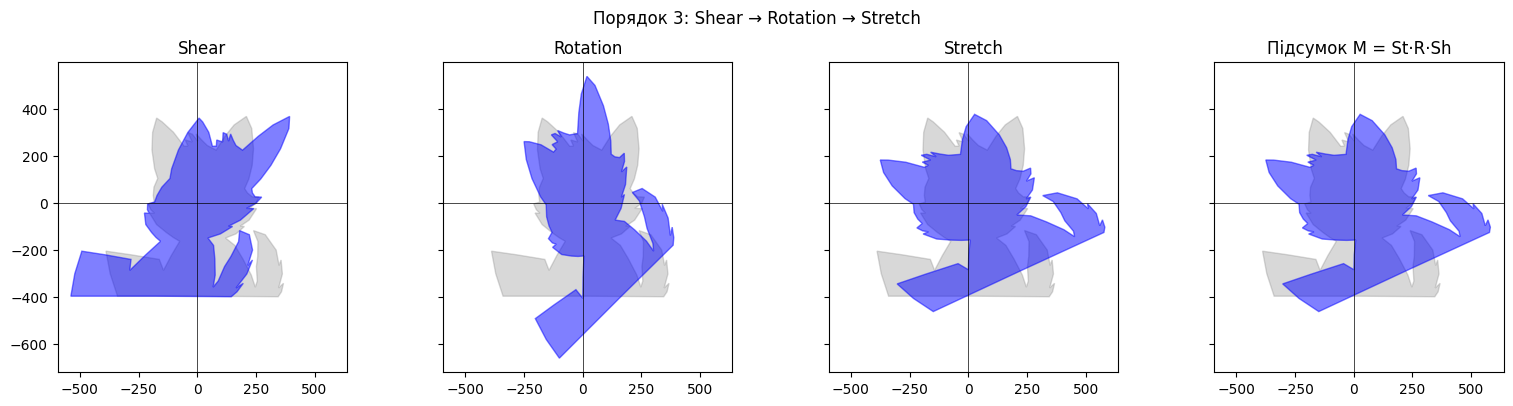

In [321]:
# Порядок 3: Shear → Rotation → Stretch
Q1, Sh = shear(L, 0.5, 0)
Q2, R  = rotation(Q1, np.pi / 4)
Q3, St = stretch(Q2, 1.5, 0.7)
M3 = St @ R @ Sh

plot_steps([(Q1, Sh, 'Shear'),
            (Q2, R,  'Rotation'),
            (Q3, St, 'Stretch'),
            (Q3, M3, 'Підсумок M = St·R·Sh')],
           'Порядок 3: Shear → Rotation → Stretch')

In [322]:
print('M1 =\n', np.round(M1, 3))
print('M2 =\n', np.round(M2, 3))
print('M3 =\n', np.round(M3, 3))
print('M1 == M2:', np.allclose(M1, M2))
print('M1 == M3:', np.allclose(M1, M3))

M1 =
 [[ 1.061 -0.247]
 [ 1.061  0.742]]
M2 =
 [[ 1.591 -0.53 ]
 [ 0.495  0.495]]
M3 =
 [[ 1.061 -0.53 ]
 [ 0.495  0.742]]
M1 == M2: False
M1 == M3: False


## Task 2

In [323]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [324]:
def read_off(filename: str):
    with open(filename, 'r') as f:
        if 'OFF' != f.readline().strip():
            raise ValueError('Not a valid OFF header')
        n_verts, n_faces, _ = map(int, f.readline().strip().split())
        verts = [list(map(float, f.readline().strip().split())) for _ in range(n_verts)]
        faces = [list(map(int, f.readline().strip().split()[1:])) for _ in range(n_faces)]
    return np.array(verts), faces

In [325]:
def plot_off(vertices, faces):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # грані з освітленням, без червоних точок і без сітки ребер
    mesh = Poly3DCollection([vertices[face] for face in faces],
                            facecolors='lightsteelblue',
                            linewidths=0,
                            shade=True)
    ax.add_collection3d(mesh)

    # однакові межі по всіх осях, щоб літак не сплющувався
    # і щоб графіки до і після повороту були в одному масштабі
    lim = np.abs(vertices).max()
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=25, azim=-60)   # однаковий ракурс камери на всіх графіках
    plt.show()

(20177, 3)
[[0, 1, 2], [1, 0, 3], [8, 9, 10]]


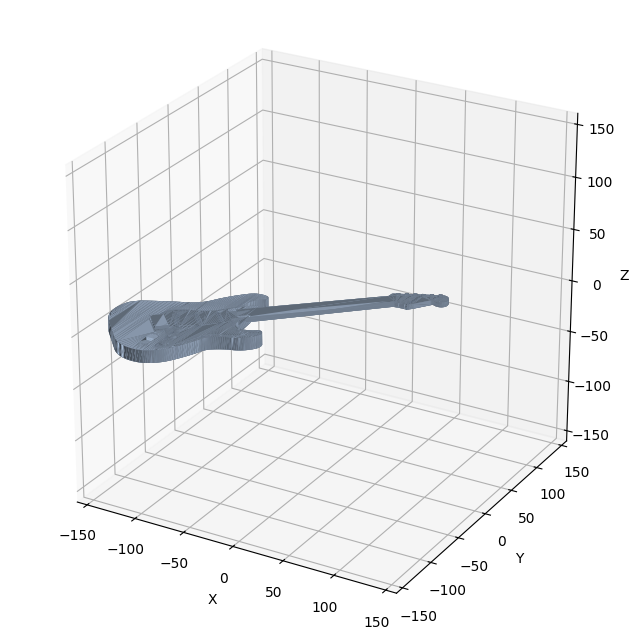

In [326]:
# vertices, faces = read_off('airplane_0627.off')
vertices, faces = read_off('guitar_0156.off')
vertices = vertices - vertices.mean(axis=0)
print(vertices.shape)
print(faces[:3])
plot_off(vertices, faces)

In [327]:
def rotate_xy(X, theta):
    X = X.copy()
    c, s = np.cos(theta), np.sin(theta)
    A = np.array([[c, -s, 0],
                  [s,  c, 0],
                  [0,  0, 1]])
    return A @ X, A

def rotate_yz(X, theta):
    X = X.copy()
    c, s = np.cos(theta), np.sin(theta)
    A = np.array([[1, 0, 0],
                  [0,  c, -s],
                  [0,  s, c]])
    return A @ X, A

def rotate_xz(X, theta):
    X = X.copy()
    c, s = np.cos(theta), np.sin(theta)
    A = np.array([[c, 0, -s],
                  [0,  1, 0],
                  [s,  0, c]])
    return A @ X, A

Rotation xy 45°
[[ 0.707 -0.707  0.   ]
 [ 0.707  0.707  0.   ]
 [ 0.     0.     1.   ]]


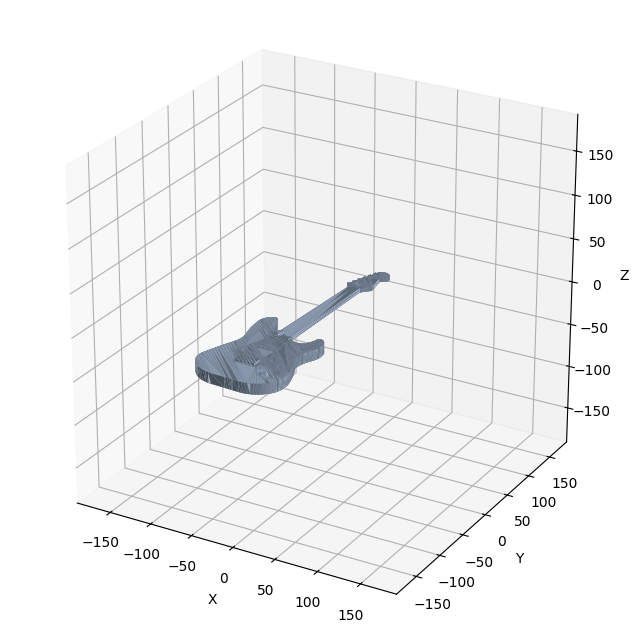

In [328]:
V1, A = rotate_xy(vertices.T, np.radians(45))
print('Rotation xy 45°')
print(np.round(A, 3))
plot_off(V1.T, faces)

Rotation yz 45°
[[ 1.     0.     0.   ]
 [ 0.     0.707 -0.707]
 [ 0.     0.707  0.707]]


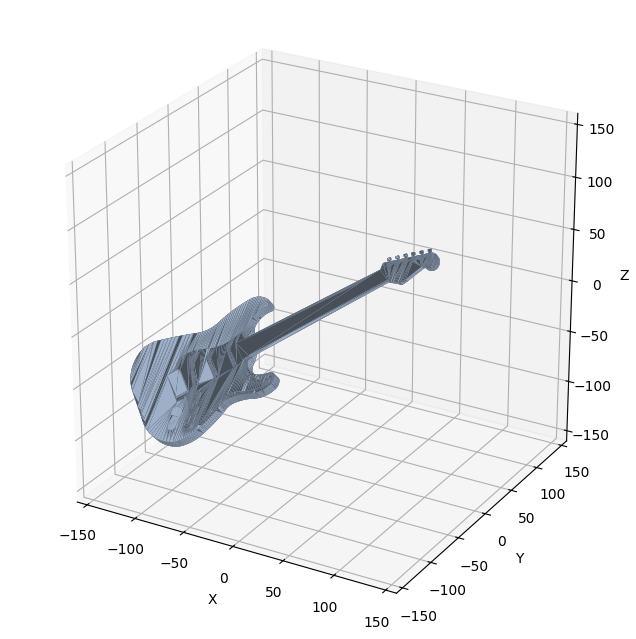

In [329]:
V2, A = rotate_yz(vertices.T, np.radians(45))
print('Rotation yz 45°')
print(np.round(A, 3))
plot_off(V2.T, faces)

Rotation xz 45°
[[ 0.707  0.    -0.707]
 [ 0.     1.     0.   ]
 [ 0.707  0.     0.707]]


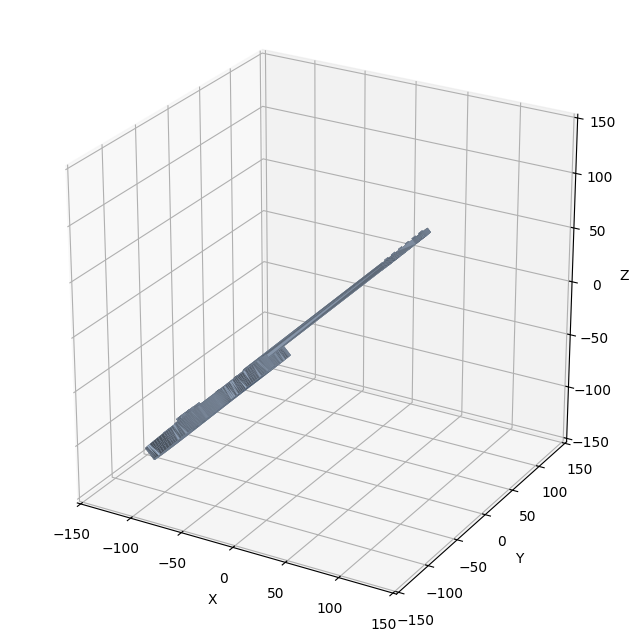

In [330]:
V3, A = rotate_xz(vertices.T, np.radians(45))
print('Rotation xz 45°')
print(np.round(A, 3))
plot_off(V3.T, faces)

Підсумкова матриця:
[[ 0.047 -0.66  -0.75 ]
 [ 0.612  0.612 -0.5  ]
 [ 0.789 -0.436  0.433]]


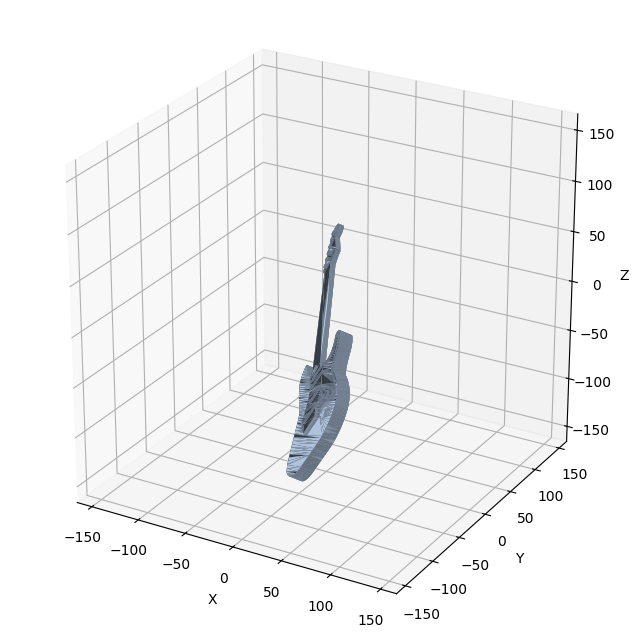

In [331]:
V = vertices.T
V1, Rxy = rotate_xy(V,  np.radians(45))
V2, Ryz = rotate_yz(V1, np.radians(30))
V3, Rxz = rotate_xz(V2, np.radians(60))

M = Rxz @ Ryz @ Rxy
print('Підсумкова матриця:')
print(np.round(M, 3))
plot_off(V3.T, faces)